**FEATURE SELECTION AND ENGINEERING**

In [64]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
import shap


c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Read in dataset
final_df=pd.read_csv(r'C:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\data\funding_model.csv')

In [3]:
final_df.head()

,Unnamed: 0,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,teachers_pay_additional_grant,mainstream_schools_additional_grant,total_funding,new_la_code,trust_or_no_trust,RECTYPE,LEA,SCHNAME,READ_AVERAGE,GPS_AVERAGE,MAT_AVERAGE
0,0,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071309,101202,3012024,Beam Primary School,Community school,Primary,No trustees,No,2250199,76801,120002,20097,126778,24466,9804,0,0,181145,564,5783.971631,216795.0,149.0,46128.0,20740.0,474,29807.0,98865.0,3705550.0,E09000002,0,1.0,301.0,Beam Primary School,109,112,108
1,1,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071301,101231,3012068,Becontree Primary School,Community school,Primary,No trustees,No,1687649,52835,81601,27666,46390,54424,4902,579,0,133961,423,5731.340426,146955.0,101.0,33510.0,19610.0,361,22359.0,74160.0,2746323.5,E09000002,0,1.0,301.0,Becontree Primary School,105,107,106
2,3,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10045428,140687,3012002,Dorothy Barley Junior Academy,Academy sponsor led,Primary,REACH2 ACADEMY TRUST,Yes,1356503,63184,100001,6544,33142,73113,19120,0,763,132682,340,5742.864706,181875.0,125.0,0.0,19390.0,339,19813.0,65784.0,2268467.5,E09000002,1,1.0,301.0,Dorothy Barley Junior Academy,104,105,103
3,4,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10056131,142699,3012006,Eastbury Primary School,Academy converter,Primary,PARTNERSHIP LEARNING,Yes,2984306,97500,155202,32103,73080,72898,13617,1157,0,192856,748,5491.457219,280815.0,193.0,63794.0,22440.0,644,38872.0,128906.0,4685461.5,E09000002,1,1.0,301.0,Eastbury Primary School,103,106,104
4,5,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10072898,101228,3012065,Five Elms Primary School,Community school,Primary,No trustees,No,1635783,73533,115201,23286,63385,12513,17473,11023,0,127679,410,5739.365854,208065.0,143.0,28743.0,19620.0,362,23306.0,77361.0,2743621.5,E09000002,0,1.0,301.0,Five Elms Primary School,105,108,105


In [4]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14968 entries, 0 to 14967
Data columns (total 44 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                14968 non-null  int64  
 1   time_period                               14968 non-null  int64  
 2   time_identifier                           14968 non-null  object 
 3   geographic_level                          14968 non-null  object 
 4   country_code                              14968 non-null  object 
 5   country_name                              14968 non-null  object 
 6   old_la_code                               14968 non-null  int64  
 7   la_name                                   14968 non-null  object 
 8   school_ukprn                              14968 non-null  int64  
 9   school_urn                                14968 non-null  int64  
 10  school_laestab                    

*Feature Engineering*

For first steps, we will engineer the three ks2 metrics into a single metric by taking an average of all three columns i.e, the READ_AVERAGE, GPS_AVERAGE and MAT_AVERAGE columns.

In [5]:
final_df['READ_AVERAGE'].unique()

array(['109', '105', '104', '103', '106', '107', '108', '111', '102',
       '110', '100', '113', '112', '99', '101', 'SUPP', '114', '98', '97',
       '96', '95', '94', '115', '116', '92'], dtype=object)

There is a value of 'SUPP' in the READ_AVERAGE, GPS_AVERAGE and MAT_AVERAGE columns which we are not entirely sure of its meaning. Lets see how often it appears.

In [6]:
len(final_df[final_df['READ_AVERAGE']=='SUPP'])

285

We could decide to drop these rows.

In [7]:
#Only keeping rows with no SUPP
final_df=final_df[final_df['READ_AVERAGE']!='SUPP']

In [8]:
#Change their data type
final_df['READ_AVERAGE']=final_df['READ_AVERAGE'].astype(float)
final_df['GPS_AVERAGE']=final_df['GPS_AVERAGE'].astype(float)
final_df['MAT_AVERAGE']=final_df['MAT_AVERAGE'].astype(float)

In [9]:
#Creating the cumulative average column (our dependent variable)
final_df['KS2_METRIC']=(final_df['READ_AVERAGE'] + final_df['GPS_AVERAGE'] + final_df['MAT_AVERAGE'])/3

*Feature selection*

To begin feature selection, we will drop columns we are sure will not be useful in the model.


In [10]:
final_df.drop(columns=['time_identifier', 'Unnamed: 0', 'time_period', 'geographic_level', 'country_code', 'country_name', 'old_la_code', 'la_name', 'school_ukprn', 'school_urn', 'school_laestab', 'school_name', 'school_phase', 'trust', 'academy', 'RECTYPE', 'LEA', 'SCHNAME', 'READ_AVERAGE', 'GPS_AVERAGE', 'MAT_AVERAGE'], inplace=True)

Next, we can encode the categorical variables school_type and new_la_code. We could easily label encode these values especially the new_la_code column. Another option might be to one hot code but this might drastically impact the dimensionality of the dataframe and thus the model.

In [11]:

# Create encoders
le1 = LabelEncoder()
le2 = LabelEncoder()

# Apply to your two columns (replace with your actual column names)
final_df['school_type_encoded'] = le1.fit_transform(final_df['school_type'])
final_df['new_la_code_encoded'] = le2.fit_transform(final_df['new_la_code'])

In [12]:
#Drop old columns
final_df.drop(columns=['school_type', 'new_la_code'], inplace=True)

From our EDA, we observed skewness in most of our numerical variables with most features being right skewed. Most ML models do not perform optimally with skewed data but instead need normall distributed data. For this reason, we will fix skewness using log transformation.

In [13]:
#Getting columns to apply log transformation
cols_to_log_transform=[cols for cols in final_df.columns if cols not in ['school_type_encoded', 'new_la_code_encoded', 'trust_or_no_trust']]
cols_to_log_transform

['basic_entitlement_primary',
 'fsm_funding',
 'fsm6_funding',
 'idaci_band_f',
 'idaci_band_e',
 'idaci_band_d',
 'idaci_band_c',
 'idaci_band_b',
 'idaci_band_a',
 'idaci_funding',
 'total_number_of_pupils',
 'allocation_per_pupil',
 'pupil_premium',
 'pupil_premium_pupils',
 'universal_infant_free_school_meals_grant',
 'pe_&_sport_premium',
 'pe_&_sport_premium_pupils',
 'teachers_pay_additional_grant',
 'mainstream_schools_additional_grant',
 'total_funding',
 'KS2_METRIC']

In [14]:
#Applying log transformation
for i in cols_to_log_transform:
    final_df[i]=np.log(final_df[i])

c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
final_df.head()

,basic_entitlement_primary,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,teachers_pay_additional_grant,mainstream_schools_additional_grant,total_funding,trust_or_no_trust,KS2_METRIC,school_type_encoded,new_la_code_encoded
0,14.626529,11.248973,11.695264,9.908326,11.750193,10.105040,9.190546,-inf,-inf,12.107053,6.335054,8.662846,12.286707,5.003946,10.739175,9.939819,6.161207,10.302499,11.501511,15.125342,0,4.697445,2,99
1,14.338847,10.874929,11.309597,10.227960,10.744839,10.904561,8.497399,6.361302,-inf,11.805304,6.047372,8.653705,11.897882,4.615121,10.419599,9.883795,5.888878,10.014984,11.213980,14.825774,0,4.663439,2,99
2,14.120421,11.053806,11.512935,8.786304,10.408557,11.199761,9.858490,-inf,6.637258,11.795711,5.828946,8.655713,12.111075,4.828314,-inf,9.872513,5.826000,9.894094,11.094132,14.634615,1,4.644391,1,99
3,14.908878,11.487608,11.952483,10.376705,11.199310,11.196816,9.519074,7.053586,-inf,12.169699,6.617403,8.610949,12.545451,5.262690,11.063414,10.018600,6.467699,10.568029,11.766839,15.359975,1,4.647591,0,99
4,14.307632,11.205490,11.654434,10.055608,11.056983,9.434523,9.768412,9.307739,-inf,11.757275,6.016157,8.655104,12.245606,4.962845,10.266150,9.884305,5.891644,10.056466,11.256238,14.824789,0,4.663439,2,99


In [22]:
#Replace the negative and positive infinity with 0
final_df.replace([np.inf, -np. inf], 0, inplace=True)


From our EDA, we spotted certain columns with strong linear correlation between each other, to avoid multicollinearity we would need to drop some of these columns. To do this, we can start by observing the correlation between our columns and our dependent variable.

<Axes: >

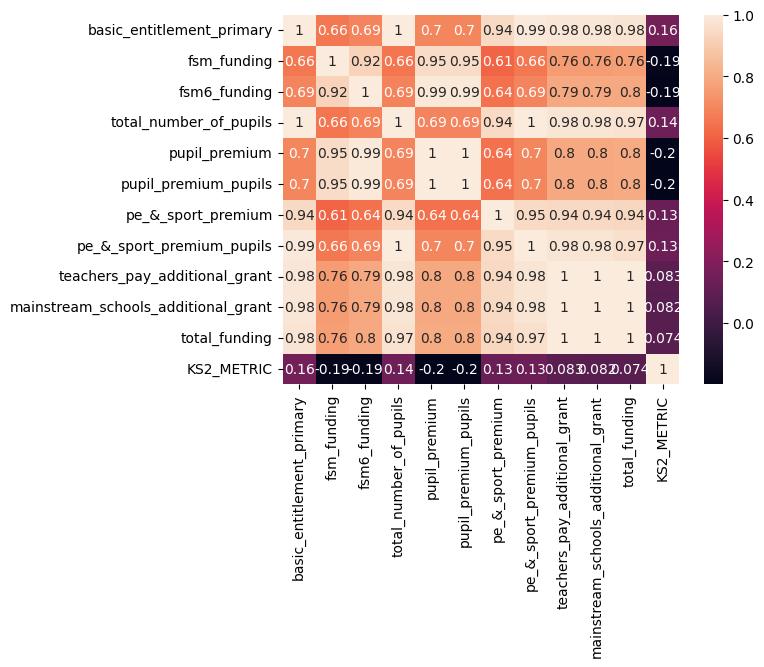

In [17]:
sns.heatmap(data=final_df[['basic_entitlement_primary', 'fsm_funding', 'fsm6_funding',
       'total_number_of_pupils',  'pupil_premium',
       'pupil_premium_pupils', 
       'pe_&_sport_premium', 'pe_&_sport_premium_pupils',
       'teachers_pay_additional_grant', 'mainstream_schools_additional_grant',
       'total_funding', 'KS2_METRIC']].corr(), annot=True)

All features seem to possess very low linear correlation with the dependent variable. So we might not be able to make a decision with a linear correlation. In its place, we could utilize the ANOVA test for dependence between the features and the dependent variable

In [20]:
#Get features
anova_cols=[cols for cols in cols_to_log_transform if cols!='KS2_METRIC']
anova_cols


['basic_entitlement_primary',
 'fsm_funding',
 'fsm6_funding',
 'idaci_band_f',
 'idaci_band_e',
 'idaci_band_d',
 'idaci_band_c',
 'idaci_band_b',
 'idaci_band_a',
 'idaci_funding',
 'total_number_of_pupils',
 'allocation_per_pupil',
 'pupil_premium',
 'pupil_premium_pupils',
 'universal_infant_free_school_meals_grant',
 'pe_&_sport_premium',
 'pe_&_sport_premium_pupils',
 'teachers_pay_additional_grant',
 'mainstream_schools_additional_grant',
 'total_funding']

In [23]:
#Applying ANOVA between numeric variables and our dependent variable
fs = SelectKBest(score_func=f_classif, k='all')
fs.fit_transform(final_df[anova_cols], final_df['KS2_METRIC'])
fs.scores_

array([ 8.99811799, 10.38919478, 11.03633399,  2.21056437,  1.82249463,
        1.67535032,  2.25069406,  4.25301433,  5.74185335,  5.02083904,
        8.35413388, 18.29951061, 11.4826231 , 12.47274795,  1.77177525,
        2.85288653,  8.03355162,  3.0108933 ,  2.75653941,  4.03284596])

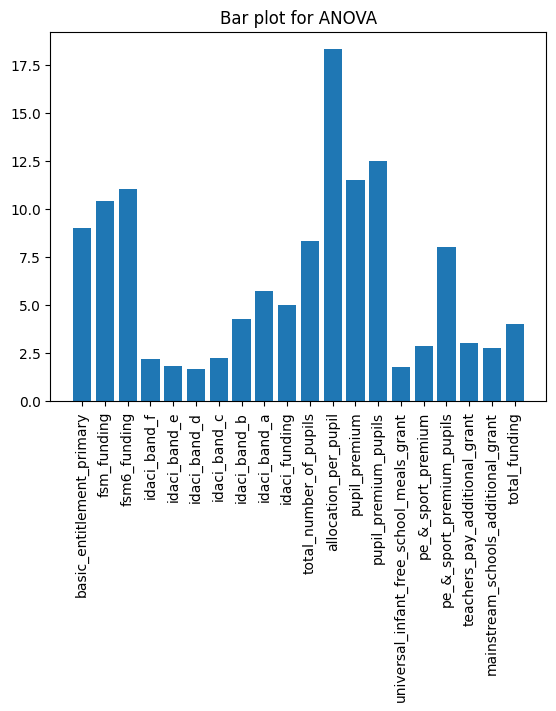

In [24]:
# Visualizing ANOVA scores using a bar plot 
plt.bar(final_df[anova_cols].columns, fs.scores_)
plt.xticks(rotation=90)
plt.title('Bar plot for ANOVA');

We will drop the following columns because they have strong correlation with other columns and little dependence on our dependent variable.
* Total funding
* PE and sport premium
* Mainstream schools additional grant

In [27]:
final_df.drop(columns=['total_funding', 'mainstream_schools_additional_grant', 'pe_&_sport_premium'], inplace=True)

In [28]:
final_df.head()

,basic_entitlement_primary,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium_pupils,teachers_pay_additional_grant,trust_or_no_trust,KS2_METRIC,school_type_encoded,new_la_code_encoded
0,14.626529,11.248973,11.695264,9.908326,11.750193,10.105040,9.190546,0.000000,0.000000,12.107053,6.335054,8.662846,12.286707,5.003946,10.739175,6.161207,10.302499,0,4.697445,2,99
1,14.338847,10.874929,11.309597,10.227960,10.744839,10.904561,8.497399,6.361302,0.000000,11.805304,6.047372,8.653705,11.897882,4.615121,10.419599,5.888878,10.014984,0,4.663439,2,99
2,14.120421,11.053806,11.512935,8.786304,10.408557,11.199761,9.858490,0.000000,6.637258,11.795711,5.828946,8.655713,12.111075,4.828314,0.000000,5.826000,9.894094,1,4.644391,1,99
3,14.908878,11.487608,11.952483,10.376705,11.199310,11.196816,9.519074,7.053586,0.000000,12.169699,6.617403,8.610949,12.545451,5.262690,11.063414,6.467699,10.568029,1,4.647591,0,99
4,14.307632,11.205490,11.654434,10.055608,11.056983,9.434523,9.768412,9.307739,0.000000,11.757275,6.016157,8.655104,12.245606,4.962845,10.266150,5.891644,10.056466,0,4.663439,2,99


*Model Building*

Building a simple random forest regressor model for our dataframe.

In [40]:
#Rearranging dataframe so that dependent variable is the last column
arranged_cols= [cols for cols in final_df if cols!='KS2_METRIC']
arranged_cols.append('KS2_METRIC')
final_df=final_df[arranged_cols ]

In [46]:
X=final_df.iloc[:, :-1].values
y=final_df.iloc[:,-1].values

In [50]:
#Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Applying Randomized Cross Validation for hyperparamter tuning to choose the best hyperparameter combination with the most accurate model score.

In [51]:
# Define the model
rf = RandomForestRegressor()

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}


In [58]:
# Randomized search with 5-fold CV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)


In [59]:
# Fit the search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\HP\Documents\Underfunding_ML_project\underfunding_venv

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='neg_mean_squared_error', verbose=2)

In [61]:
# Best model
best_model = random_search.best_estimator_
best_model

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=4,
                      n_estimators=300)

In [63]:
#Get RMSE
np.sqrt(-random_search.best_score_)

np.float64(0.022490747626462977)

We get an RMSE of 0.0224, which is a very good value, however there's a chance of overfitting which is something to think about considering our dataset size.

*SHAP analysis*

SHAP (SHapley Additive exPlanations) analysis is a game theory based algorithm explaining the impact of features on a machine learning model. Unlike other methods of getting feature importance, SHAP is able to get individual feature importance providing better insights.

In [66]:

# Create SHAP explainer for tree-based models
explainer = shap.Explainer(best_model, X_train)

# Compute SHAP values for test set
shap_values = explainer(X_test)

100%|===================| 2936/2937 [10:40<00:00]        

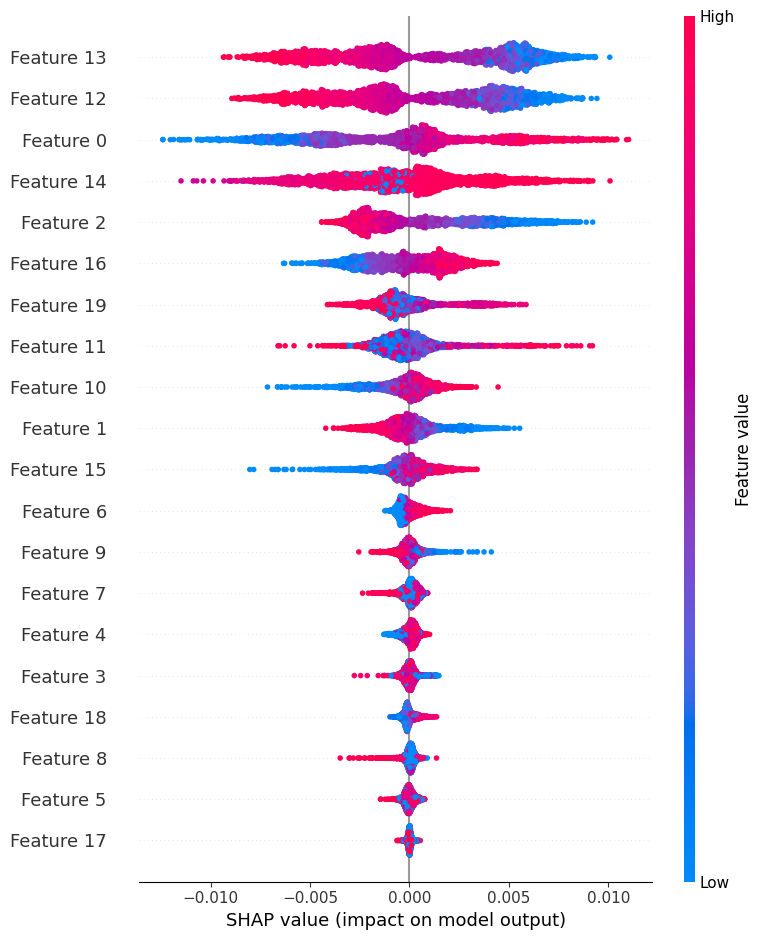

In [68]:
shap.summary_plot(shap_values, X_test)
